# 0. Project Overview

This project analyzes the performance of a control campaign and a test campaign using A/B testing methods.

The goal is to determine whether the test campaign improved marketing performance compared with the control campaign.

The analysis focuses on key marketing KPIs including click-through rate, conversion rate, cost per purchase, and final purchase outcomes.

# Business Recommendation

Although the test campaign improved click-through performance, it did not generate a statistically significant increase in purchases.

The control campaign demonstrated stronger conversion efficiency and lower acquisition cost.

Based on the analysis, the control campaign should be preferred unless the test campaign can be improved to attract higher-intent traffic.

# 1. Data Cleaning

## 1.1 Dataset Overview

In [ ]:
import pandas as pd

control = pd.read_csv('/content/control_group.csv', sep=';')
test = pd.read_csv('/content/test_group.csv', sep=';')

print("Control shape:", control.shape)
print("Test shape:", test.shape)

display(control.head(5))
display(test.head(5))

print(control.info())
print(test.info())

Control shape: (30, 10)
Test shape: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Campaign Name        30 non-null     object 
 1   Date                 30 non-null     object 
 2   Spend [USD]          30 non-null     int64  
 3   # of Impressions     29 non-null     float64
 4   Reach                29 non-null     float64
 5   # of Website Clicks  29 non-null     float64
 6   # of Searches        29 non-null     float64
 7   # of View Content    29 non-null     float64
 8   # of Add to Cart     29 non-null     float64
 9   # of Purchase        29 non-null     float64
dtypes: float64(7), int64(1), object(2)
memory usage: 2.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Campaign Name        30 

## 1.2 Data Cleaning

deal with NA

In [ ]:
control.isnull().sum()

,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,1
Reach,1
# of Website Clicks,1
# of Searches,1
# of View Content,1
# of Add to Cart,1
# of Purchase,1


In [ ]:
control = control.dropna()

In [ ]:
control.shape

(29, 10)

change column names

In [ ]:
control.columns = [
    'Campaign',
    'Date',
    'Spend',
    'Impressions',
    'Reach',
    'Website_Clicks',
    'Searches',
    'View_Content',
    'Add_to_Cart',
    'Purchase'
]

test.columns = [
    'Campaign',
    'Date',
    'Spend',
    'Impressions',
    'Reach',
    'Website_Clicks',
    'Searches',
    'View_Content',
    'Add_to_Cart',
    'Purchase'
]

date format

In [ ]:
control['Date'] = pd.to_datetime(control['Date'], format='%d.%m.%Y')
test['Date'] = pd.to_datetime(test['Date'], format='%d.%m.%Y')

check

In [ ]:
print(control.info())
print(test.info())

display(control.head())

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 29
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Campaign        29 non-null     object        
 1   Date            29 non-null     datetime64[ns]
 2   Spend           29 non-null     int64         
 3   Impressions     29 non-null     float64       
 4   Reach           29 non-null     float64       
 5   Website_Clicks  29 non-null     float64       
 6   Searches        29 non-null     float64       
 7   View_Content    29 non-null     float64       
 8   Add_to_Cart     29 non-null     float64       
 9   Purchase        29 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 2.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  

,Campaign,Date,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
5,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0


# 2. EDA (Exploratory Data Analysis)

## 2.1 Merge Datasets

In [ ]:
df = pd.concat([control, test], ignore_index=True)

display(df.head())

print(df.shape)

,Campaign,Date,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0


(59, 10)


## 2.2 Overall Lookup

In [ ]:
df.groupby('Campaign').mean(numeric_only=True).round()

,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
Campaign,,,,,,,,
Control Campaign,2304.0,109560.0,88845.0,5321.0,2221.0,1944.0,1300.0,523.0
Test Campaign,2563.0,74585.0,53492.0,6032.0,2419.0,1858.0,882.0,521.0


Test campaign improved engagement
BUT
did not significantly improve final conversions.

## 2.3 Core KPI

In [ ]:
df['CTR'] = df['Website_Clicks'] / df['Impressions']

df['Conversion_Rate'] = df['Purchase'] / df['Website_Clicks']

df['Cost_per_Purchase'] = df['Spend'] / df['Purchase']

In [ ]:
kpi = df.groupby('Campaign')[
    ['CTR', 'Conversion_Rate', 'Cost_per_Purchase']
].mean()

kpi['CTR'] = (kpi['CTR'] * 100).round(2).astype(str) + '%'

kpi['Conversion_Rate'] = (
    kpi['Conversion_Rate'] * 100
).round(2).astype(str) + '%'

kpi['Cost_per_Purchase'] = (
    '$' + kpi['Cost_per_Purchase'].round(2).astype(str)
)

display(kpi)

,CTR,Conversion_Rate,Cost_per_Purchase
Campaign,,,
Control Campaign,5.1%,11.48%,$5.05
Test Campaign,10.24%,9.23%,$5.9


(Not statistically real) The test campaign generated significantly higher click-through rates,
indicating stronger ad engagement and user interest.

However, the increased traffic did not translate into improved purchase conversions.
The control campaign maintained a higher conversion rate and lower cost per purchase,
suggesting stronger overall conversion efficiency and marketing ROI.

# 3. Hypothesis Testing

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
t_stat, p_value = ttest_ind(
    control['Purchase'],
    test['Purchase']
)

print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))

t-statistic: 0.0301
p-value: 0.9761


An independent two-sample t-test was conducted to compare purchase performance between the control and test campaigns.

The analysis showed no statistically significant difference in purchases between the two groups (p = 0.9761), suggesting that the test campaign did not meaningfully improve final conversion outcomes.

# 4. Confidence Interval

In [ ]:
import scipy.stats as stats
import numpy as np

In [ ]:
control_mean = control['Purchase'].mean()
test_mean = test['Purchase'].mean()

difference = test_mean - control_mean

print("Mean Difference:", round(difference, 2))

Mean Difference: -1.56


In [ ]:
control_purchase = control['Purchase']
test_purchase = test['Purchase']

mean_diff = test_purchase.mean() - control_purchase.mean()

std_error = np.sqrt(
    (test_purchase.var(ddof=1) / len(test_purchase)) +
    (control_purchase.var(ddof=1) / len(control_purchase))
)

confidence_level = 0.95

degrees_freedom = len(test_purchase) + len(control_purchase) - 2

t_critical = stats.t.ppf(
    (1 + confidence_level) / 2,
    degrees_freedom
)

margin_of_error = t_critical * std_error

ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print("95% Confidence Interval:")
print((round(ci_lower, 2), round(ci_upper, 2)))

95% Confidence Interval:
(np.float64(-104.94), np.float64(101.82))


Although the test campaign significantly improved click-through rates and user engagement,
the experiment did not generate a statistically significant increase in purchases.

The higher traffic generated by the test campaign showed weaker conversion efficiency
and higher acquisition costs, suggesting that the additional engagement may have come from lower-intent users.

Based on the statistical analysis, the control campaign demonstrated stronger overall marketing efficiency and ROI.

# 5. Data Visualization

## 5.1 CTR

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
display(kpi)

,CTR,Conversion_Rate,Cost_per_Purchase
Campaign,,,
Control Campaign,5.1%,11.48%,$5.05
Test Campaign,10.24%,9.23%,$5.9


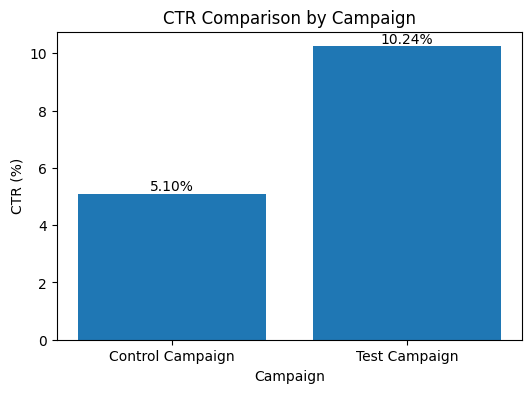

In [ ]:
kpi_summary = df.groupby('Campaign')[
    ['CTR', 'Conversion_Rate', 'Cost_per_Purchase']
].mean()

kpi_summary_display = kpi_summary.copy()

kpi_summary_display['CTR'] = kpi_summary_display['CTR'] * 100
kpi_summary_display['Conversion_Rate'] = kpi_summary_display['Conversion_Rate'] * 100

#kpi_summary_display.round(2)

plt.figure(figsize=(6, 4))

plt.bar(
    kpi_summary_display.index,
    kpi_summary_display['CTR']
)

plt.title('CTR Comparison by Campaign')
plt.ylabel('CTR (%)')
plt.xlabel('Campaign')

for i, value in enumerate(kpi_summary_display['CTR']):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

The test campaign achieved a much higher CTR than the control campaign, indicating stronger top-funnel engagement.

## 5.2 Conversion Rate

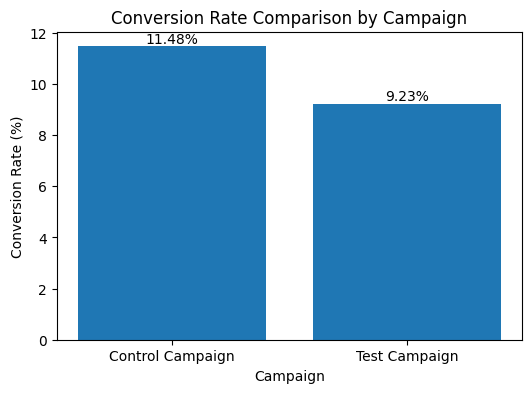

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    kpi_summary_display.index,
    kpi_summary_display['Conversion_Rate']
)

plt.title('Conversion Rate Comparison by Campaign')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Campaign')

for i, value in enumerate(kpi_summary_display['Conversion_Rate']):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

Although the test campaign generated more clicks, the control campaign had a higher purchase conversion rate.

## 5.3 Cost per Purchase

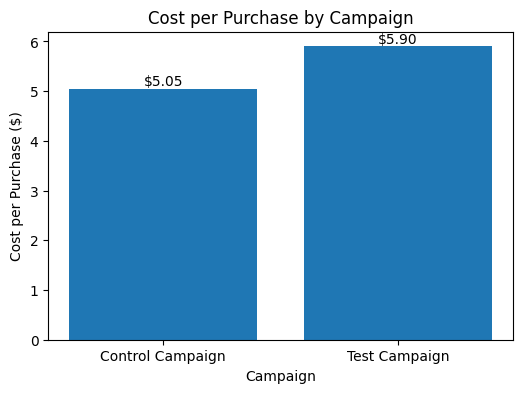

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    kpi_summary_display.index,
    kpi_summary_display['Cost_per_Purchase']
)

plt.title('Cost per Purchase by Campaign')
plt.ylabel('Cost per Purchase ($)')
plt.xlabel('Campaign')

for i, value in enumerate(kpi_summary_display['Cost_per_Purchase']):
    plt.text(i, value, f'${value:.2f}', ha='center', va='bottom')

plt.show()

The control campaign had a lower cost per purchase, suggesting better cost efficiency and stronger marketing ROI.

## 5.4 Conversion Funnel

In [ ]:
funnel_control = [
    control['Impressions'].mean(),
    control['Website_Clicks'].mean(),
    control['View_Content'].mean(),
    control['Add_to_Cart'].mean(),
    control['Purchase'].mean()
]

funnel_test = [
    test['Impressions'].mean(),
    test['Website_Clicks'].mean(),
    test['View_Content'].mean(),
    test['Add_to_Cart'].mean(),
    test['Purchase'].mean()
]

stages = [
    'Impressions',
    'Clicks',
    'View Content',
    'Add to Cart',
    'Purchase'
]

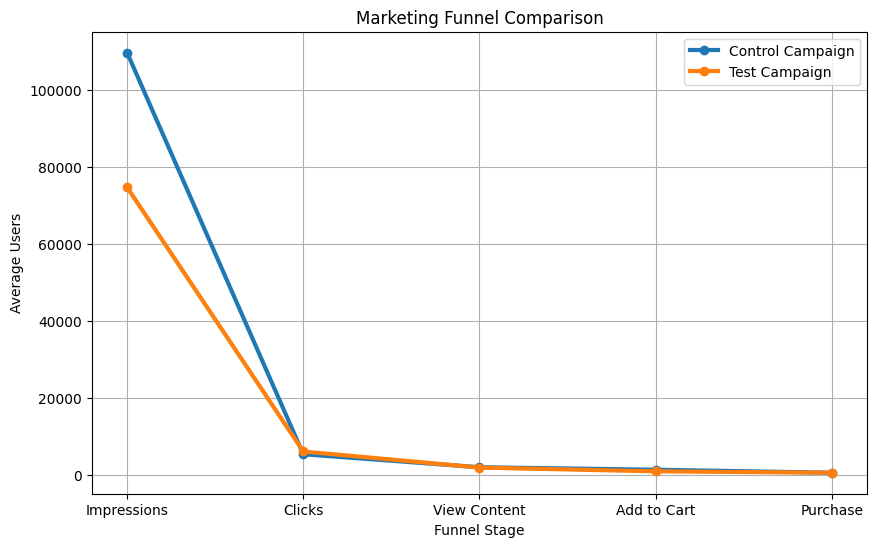

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    stages,
    funnel_control,
    marker='o',
    linewidth=3,
    label='Control Campaign'
)

plt.plot(
    stages,
    funnel_test,
    marker='o',
    linewidth=3,
    label='Test Campaign'
)

plt.title('Marketing Funnel Comparison')
plt.ylabel('Average Users')
plt.xlabel('Funnel Stage')

plt.legend()

plt.grid(True)

plt.show()

The test campaign generated significantly stronger top-funnel engagement,
with substantially higher click-through rates.

However, downstream conversion performance weakened during later funnel stages,
indicating that the additional traffic may have consisted of lower-intent users.

## 5.5 Purchase Boxplot

/tmp/ipykernel_1655/3961556125.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


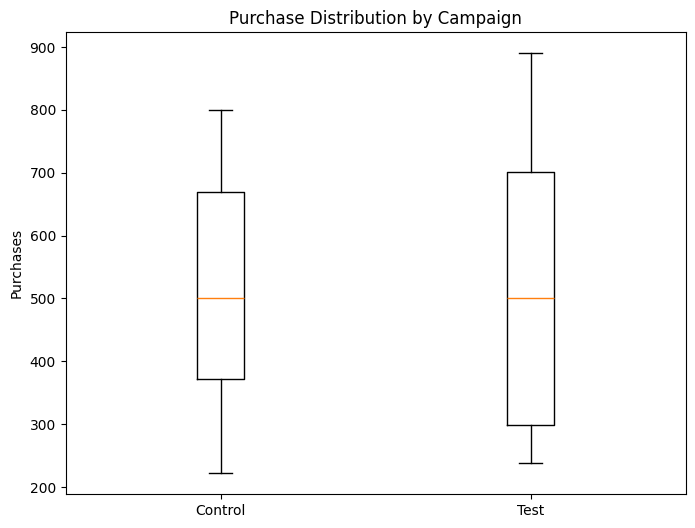

In [ ]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        control['Purchase'],
        test['Purchase']
    ],
    labels=['Control', 'Test']
)

plt.title('Purchase Distribution by Campaign')
plt.ylabel('Purchases')

plt.show()

The boxplots revealed substantial overlap in purchase distributions between the two campaigns, visually supporting the statistical test results indicating no significant difference in purchase outcomes.


## 5.6 Conversion Rate Boxplot

/tmp/ipykernel_1655/3419697882.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


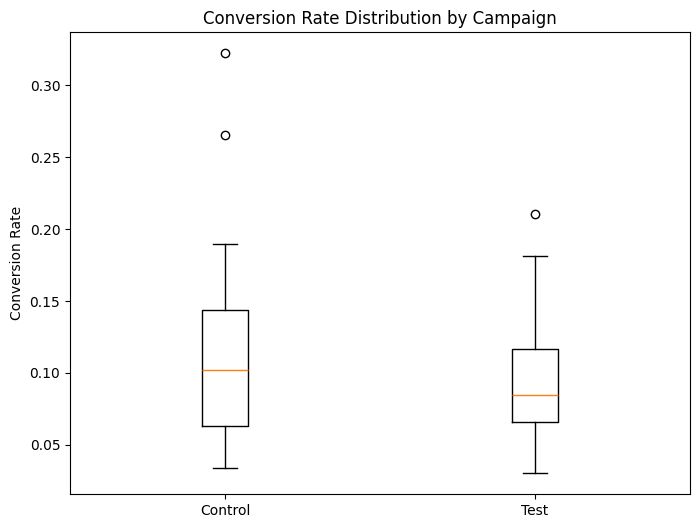

In [ ]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        control['Purchase'] / control['Website_Clicks'],
        test['Purchase'] / test['Website_Clicks']
    ],
    labels=['Control', 'Test']
)

plt.title('Conversion Rate Distribution by Campaign')
plt.ylabel('Conversion Rate')

plt.show()

Additionally, the control campaign demonstrated a higher median conversion rate and several high-performing outlier periods, suggesting stronger traffic quality and conversion efficiency.

# 6. Trend Analysis

## 6.1 Purchase Trend

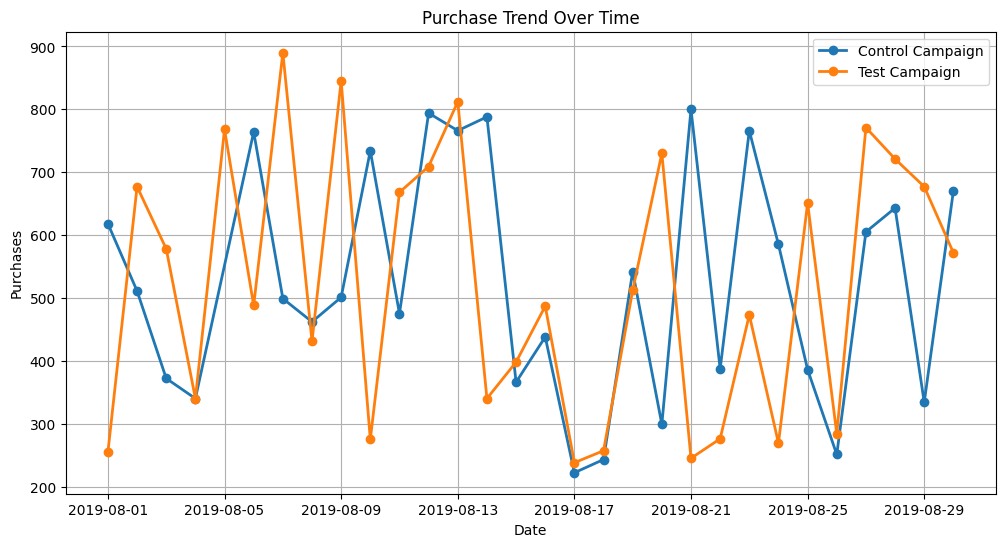

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    control['Date'],
    control['Purchase'],
    marker='o',
    linewidth=2,
    label='Control Campaign'
)

plt.plot(
    test['Date'],
    test['Purchase'],
    marker='o',
    linewidth=2,
    label='Test Campaign'
)

plt.title('Purchase Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Purchases')

plt.legend()

plt.grid(True)

plt.show()

## 6.2 CTR Trend

In [ ]:
control['CTR'] = control['Website_Clicks'] / control['Impressions']
test['CTR'] = test['Website_Clicks'] / test['Impressions']

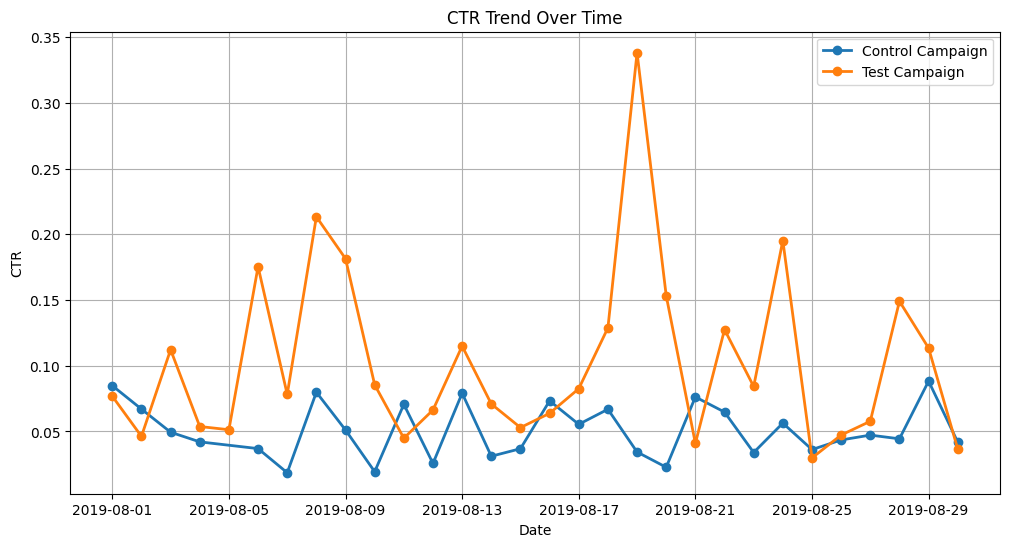

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    control['Date'],
    control['CTR'],
    marker='o',
    linewidth=2,
    label='Control Campaign'
)

plt.plot(
    test['Date'],
    test['CTR'],
    marker='o',
    linewidth=2,
    label='Test Campaign'
)

plt.title('CTR Trend Over Time')
plt.xlabel('Date')
plt.ylabel('CTR')

plt.legend()

plt.grid(True)

plt.show()

## 6.3 Conversion Trend

In [ ]:
control['Conversion_Rate'] = (
    control['Purchase'] / control['Website_Clicks']
)

test['Conversion_Rate'] = (
    test['Purchase'] / test['Website_Clicks']
)

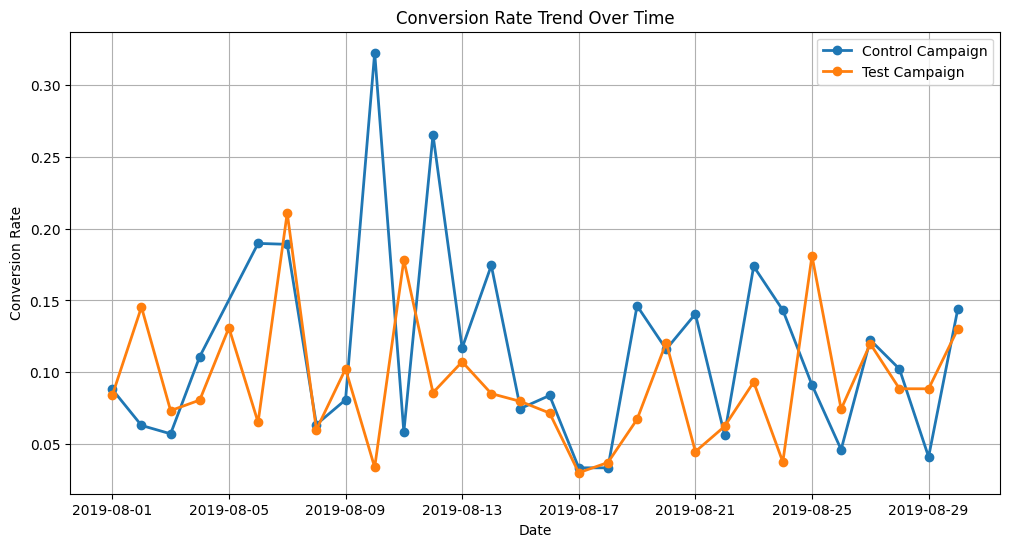

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    control['Date'],
    control['Conversion_Rate'],
    marker='o',
    linewidth=2,
    label='Control Campaign'
)

plt.plot(
    test['Date'],
    test['Conversion_Rate'],
    marker='o',
    linewidth=2,
    label='Test Campaign'
)

plt.title('Conversion Rate Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')

plt.legend()

plt.grid(True)

plt.show()

The test campaign significantly improved top-funnel engagement and click-through performance, indicating stronger ad attractiveness and user interest.

However, the increased traffic failed to translate into stronger downstream conversion outcomes. The control campaign consistently demonstrated higher conversion efficiency and lower acquisition costs.

Trend analysis and statistical testing both suggested that the test campaign did not generate a statistically significant improvement in purchase performance, despite higher engagement metrics.

Overall, the findings indicate that the test campaign attracted higher volumes of lower-intent traffic, resulting in weaker overall marketing ROI.

# 7. Heatmap

In [ ]:
correlation = df[
    [
        'Spend',
        'Impressions',
        'Reach',
        'Website_Clicks',
        'Searches',
        'View_Content',
        'Add_to_Cart',
        'Purchase'
    ]
].corr()

correlation.round(2)

,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
Spend,1.00,-0.06,-0.11,-0.06,0.02,-0.02,-0.14,0.03
Impressions,-0.06,1.00,0.89,-0.21,-0.18,-0.07,0.28,0.05
Reach,-0.11,0.89,1.00,-0.27,-0.13,-0.04,0.24,0.04
Website_Clicks,-0.06,-0.21,-0.27,1.00,0.37,0.42,-0.00,-0.03
Searches,0.02,-0.18,-0.13,0.37,1.00,0.89,0.03,0.04
View_Content,-0.02,-0.07,-0.04,0.42,0.89,1.00,0.15,0.06
Add_to_Cart,-0.14,0.28,0.24,-0.00,0.03,0.15,1.00,0.39
Purchase,0.03,0.05,0.04,-0.03,0.04,0.06,0.39,1.00


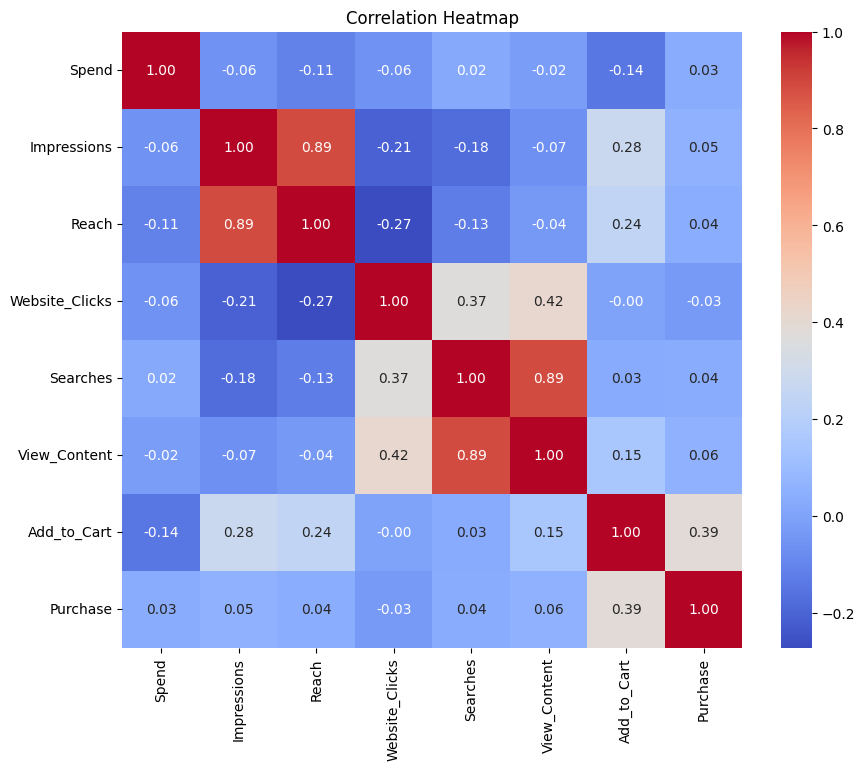

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Correlation analysis revealed that top-funnel engagement metrics such as impressions and website clicks had weak relationships with final purchase outcomes.

The strongest behavioral relationship was observed between add-to-cart actions and purchases, suggesting that downstream funnel activity was more predictive of conversion success.

Additionally, website clicks showed almost no correlation with purchases, reinforcing the earlier finding that the test campaign generated higher engagement but lower-quality traffic.